In [1]:
# =========================
# Cell 1 — Load Feature Dataset
# =========================

import pandas as pd
from pathlib import Path

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(DATA_PROCESSED / "stock_features_daily.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (56390, 15)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Sector', 'Return', 'Vol_30', 'Mom_20', 'Drawdown', 'Market_Return', 'Market_Vol_30', 'Rel_Return']


,Date,Open,High,Low,Close,Volume,Ticker,Sector,Return,Vol_30,Mom_20,Drawdown,Market_Return,Market_Vol_30,Rel_Return
0,2014-02-19,16.000,16.000,15.775,16.000,27204,ACL-N0000.CM,Industrial,-0.007752,0.020897,-0.058824,-0.132791,-0.005328,0.007856,-0.002424
1,2014-02-20,15.775,16.000,15.775,16.000,432,ACL-N0000.CM,Industrial,0.000000,0.020897,-0.058824,-0.132791,-0.005459,0.007921,0.005459
2,2014-02-21,15.900,16.000,15.750,16.000,236280,ACL-N0000.CM,Industrial,0.000000,0.020891,-0.124487,-0.132791,-0.000051,0.007893,0.000051
3,2014-02-24,15.525,16.125,15.500,15.500,138440,ACL-N0000.CM,Industrial,-0.031250,0.021324,-0.159892,-0.159892,-0.008236,0.007973,-0.023014
4,2014-02-25,15.500,15.500,15.000,15.025,546996,ACL-N0000.CM,Industrial,-0.030645,0.021875,-0.173315,-0.185637,-0.007632,0.007393,-0.023014


In [2]:
# =========================
# Cell 2 — Build Feature Matrix
# =========================

feature_cols = [
    "Return",
    "Vol_30",
    "Mom_20",
    "Drawdown",
    "Market_Return",
    "Market_Vol_30",
    "Rel_Return"
]

X = df[feature_cols].copy()

print("Feature matrix shape:", X.shape)
print("Columns used:", feature_cols)

X.head()

Feature matrix shape: (56390, 7)
Columns used: ['Return', 'Vol_30', 'Mom_20', 'Drawdown', 'Market_Return', 'Market_Vol_30', 'Rel_Return']


,Return,Vol_30,Mom_20,Drawdown,Market_Return,Market_Vol_30,Rel_Return
0,-0.007752,0.020897,-0.058824,-0.132791,-0.005328,0.007856,-0.002424
1,0.000000,0.020897,-0.058824,-0.132791,-0.005459,0.007921,0.005459
2,0.000000,0.020891,-0.124487,-0.132791,-0.000051,0.007893,0.000051
3,-0.031250,0.021324,-0.159892,-0.159892,-0.008236,0.007973,-0.023014
4,-0.030645,0.021875,-0.173315,-0.185637,-0.007632,0.007393,-0.023014


In [3]:
# =========================
# Cell 3 — Standard Scaling
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("Mean (approx):", X_scaled.mean(axis=0).round(3))
print("Std (approx):", X_scaled.std(axis=0).round(3))

Scaled shape: (56390, 7)
Mean (approx): [ 0.  0. -0.  0. -0. -0. -0.]
Std (approx): [1. 1. 1. 1. 1. 1. 1.]


In [4]:
# =========================
# Cell 4 — Train Isolation Forest
# =========================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # 2% anomalies
    random_state=42
)

iso.fit(X_scaled)

df["Anomaly_Flag"] = iso.predict(X_scaled)
df["Anomaly_Score"] = iso.decision_function(X_scaled)

print("Total anomalies detected:", (df["Anomaly_Flag"] == -1).sum())
print("Percentage anomalous:",
      round((df["Anomaly_Flag"] == -1).mean() * 100, 2), "%")

df[["Date","Ticker","Anomaly_Flag","Anomaly_Score"]].head()

Total anomalies detected: 1128
Percentage anomalous: 2.0 %


,Date,Ticker,Anomaly_Flag,Anomaly_Score
0,2014-02-19,ACL-N0000.CM,1,0.231896
1,2014-02-20,ACL-N0000.CM,1,0.233721
2,2014-02-21,ACL-N0000.CM,1,0.228839
3,2014-02-24,ACL-N0000.CM,1,0.159436
4,2014-02-25,ACL-N0000.CM,1,0.158083


In [5]:
# =========================
# Cell 5 — Inspect Top Anomalies
# =========================

df_anom = df[df["Anomaly_Flag"] == -1].copy()

df_anom = df_anom.sort_values("Anomaly_Score")

df_anom[[
    "Date",
    "Ticker",
    "Sector",
    "Return",
    "Vol_30",
    "Rel_Return",
    "Drawdown",
    "Anomaly_Score"
]].head(10)

,Date,Ticker,Sector,Return,Vol_30,Rel_Return,Drawdown,Anomaly_Score
4792,2022-04-27,BIL-N0000.CM,Diversified,0.365854,0.098105,0.276417,-0.698925,-0.167711
25663,2022-04-27,EXPO-N0000.CM,Telecom,0.447633,0.107899,0.358197,-0.639272,-0.166175
7117,2020-09-28,BUKI-N0000.CM,Consumer,0.698690,0.131551,0.659547,-0.313188,-0.164509
42023,2022-04-28,LOLC-N0000.CM,Banking/Finance,0.262997,0.099525,0.219659,-0.713840,-0.163915
39303,2022-05-23,LIOC-N0000.CM,Industrial,0.200000,0.096674,0.168541,-0.312916,-0.162885
42022,2022-04-27,LOLC-N0000.CM,Banking/Finance,0.215613,0.084554,0.126177,-0.773428,-0.158430
41694,2021-01-22,LOLC-N0000.CM,Banking/Finance,0.250000,0.081749,0.201267,0.000000,-0.158058
4810,2022-05-23,BIL-N0000.CM,Diversified,0.130952,0.098849,0.099493,-0.489247,-0.152367
41707,2021-02-10,LOLC-N0000.CM,Banking/Finance,-0.131985,0.098476,-0.064350,-0.217746,-0.148169
2055,2022-04-27,ACL-N0000.CM,Industrial,0.235795,0.071674,0.146359,-0.659491,-0.147156


In [6]:
# =========================
# Cell 6 — Monthly Anomaly Counts 
# =========================

df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

monthly_anomaly = (
    df[df["Anomaly_Flag"] == -1]
    .groupby("Month")
    .size()
)

all_months = df["Month"].drop_duplicates().sort_values()

monthly_df = (
    monthly_anomaly
    .reindex(all_months, fill_value=0)
    .reset_index()
)

monthly_df.columns = ["Month", "Anomaly_Count"]

print("Total months:", len(monthly_df))
print("Months with zero anomalies:",
      (monthly_df["Anomaly_Count"] == 0).sum())

monthly_df.head()

Total months: 131
Months with zero anomalies: 56


,Month,Anomaly_Count
0,2014-02-01,0
1,2014-03-01,0
2,2014-04-01,0
3,2014-05-01,0
4,2014-06-01,1


In [7]:
# =========================
# Cell 7 — Regime Classification (Percentile-Based)
# =========================

p75 = monthly_df["Anomaly_Count"].quantile(0.75)
p95 = monthly_df["Anomaly_Count"].quantile(0.95)

print("75th percentile:", p75)
print("95th percentile:", p95)

def classify_regime(x):
    if x >= p95:
        return "Crisis"
    elif x > p75:
        return "Elevated"
    else:
        return "Normal"

monthly_df["Regime"] = monthly_df["Anomaly_Count"].apply(classify_regime)

monthly_df.sort_values("Anomaly_Count", ascending=False).head(15)

75th percentile: 5.0
95th percentile: 49.0


,Month,Anomaly_Count,Regime
98,2022-04-01,133,Crisis
99,2022-05-01,129,Crisis
84,2021-02-01,100,Crisis
97,2022-03-01,72,Crisis
75,2020-05-01,64,Crisis
80,2020-10-01,60,Crisis
83,2021-01-01,54,Crisis
102,2022-08-01,44,Elevated
73,2020-03-01,38,Elevated
100,2022-06-01,37,Elevated


In [8]:
# =========================
# Cell 8 — Merge Regime into Daily Data
# =========================

df = df.merge(
    monthly_df[["Month", "Regime"]],
    on="Month",
    how="left"
)

print("Missing regime rows:",
      df["Regime"].isna().sum())

df[["Date","Ticker","Regime"]].head()

Missing regime rows: 0


,Date,Ticker,Regime
0,2014-02-19,ACL-N0000.CM,Normal
1,2014-02-20,ACL-N0000.CM,Normal
2,2014-02-21,ACL-N0000.CM,Normal
3,2014-02-24,ACL-N0000.CM,Normal
4,2014-02-25,ACL-N0000.CM,Normal


In [9]:
# =========================
# Cell 9 — Build Daily Ranked Watchlist (Sector-Constrained)
# =========================

df["Attention_Score"] = -df["Anomaly_Score"]

min_score = df["Attention_Score"].min()
if min_score < 0:
    df["Attention_Score"] = df["Attention_Score"] - min_score

# Sort by date and attention score
rank_df = df.sort_values(["Date", "Attention_Score"], ascending=[True, False]).copy()

# Sector diversification rule: maximum 2 stocks per sector per day
rank_df["Sector_Rank"] = (
    rank_df.groupby(["Date", "Sector"])["Attention_Score"]
    .rank(method="first", ascending=False)
)

sector_filtered = rank_df[rank_df["Sector_Rank"] <= 2].copy()

# Final daily rank after sector filtering
sector_filtered["Daily_Rank"] = (
    sector_filtered.groupby("Date")["Attention_Score"]
    .rank(method="first", ascending=False)
)

daily_watchlist = sector_filtered[sector_filtered["Daily_Rank"] <= 5].copy()

print("Watchlist rows:", len(daily_watchlist))
daily_watchlist[[
    "Date", "Ticker", "Sector", "Attention_Score", "Daily_Rank", "Regime"
]].head(15)

Watchlist rows: 13695


,Date,Ticker,Sector,Attention_Score,Daily_Rank,Regime
42704,2014-02-19,MAL-N0000.CM,Consumer,0.133214,1.0,Normal
50916,2014-02-19,SAMP-N0000.CM,Banking/Finance,0.099331,2.0,Normal
8211,2014-02-19,CARG-N0000.CM,Consumer,0.093136,3.0,Normal
13685,2014-02-19,CTHR-N0000.CM,Industrial,0.057712,4.0,Normal
10948,2014-02-19,COMB-N0000.CM,Banking/Finance,0.051629,5.0,Normal
23609,2014-02-20,EXPO-N0000.CM,Telecom,0.155422,1.0,Normal
16423,2014-02-20,DFCC-N0000.CM,Banking/Finance,0.056448,2.0,Normal
5475,2014-02-20,BUKI-N0000.CM,Consumer,0.055924,3.0,Normal
26281,2014-02-20,HAYL-N0000.CM,Diversified,0.054081,4.0,Normal
10949,2014-02-20,COMB-N0000.CM,Banking/Finance,0.044559,5.0,Normal


In [10]:
# =========================
# Final Cell — Save Outputs
# =========================

WATCHLIST_PATH = DATA_PROCESSED / "risk_aware_daily_watchlist.csv"
REGIME_PATH = DATA_PROCESSED / "monthly_market_regime.csv"

daily_watchlist.to_csv(WATCHLIST_PATH, index=False)
monthly_df.to_csv(REGIME_PATH, index=False)

print("Watchlist saved:", WATCHLIST_PATH.exists())
print("Monthly regime saved:", REGIME_PATH.exists())
print("Total watchlist rows:", len(daily_watchlist))
print("Total months:", len(monthly_df))

Watchlist saved: True
Monthly regime saved: True
Total watchlist rows: 13695
Total months: 131


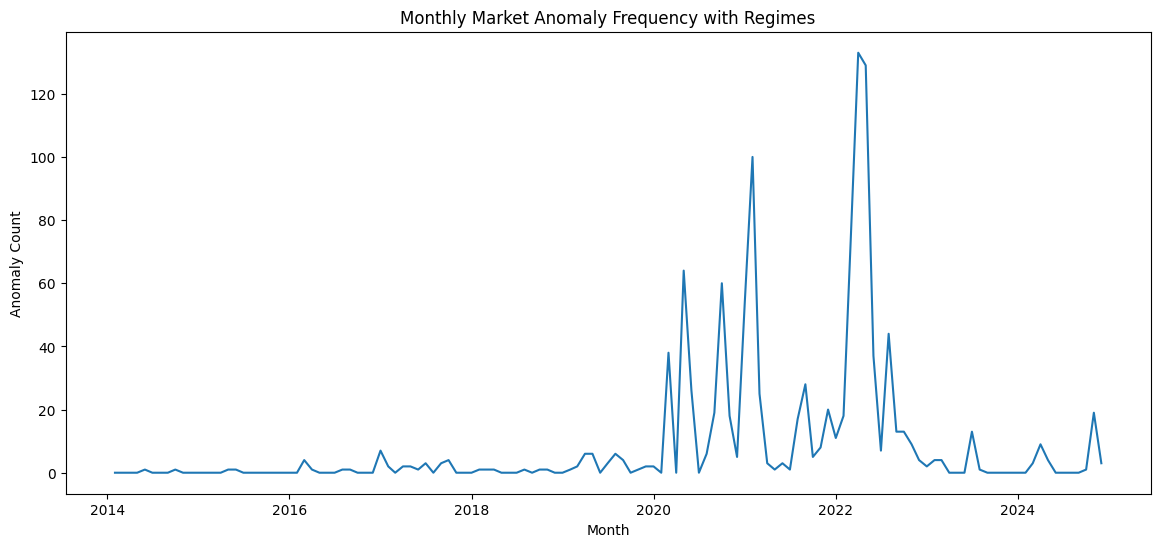

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(monthly_df["Month"], monthly_df["Anomaly_Count"])

for _, row in monthly_df.iterrows():
    if row["Regime"] == "Crisis":
        plt.axvspan(row["Month"], row["Month"], alpha=0.2)

plt.title("Monthly Market Anomaly Frequency with Regimes")
plt.xlabel("Month")
plt.ylabel("Anomaly Count")
plt.show()